In [5]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, HumanMessage
from pydantic import BaseModel
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai.embeddings import OpenAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import ChatPromptTemplate
import re

In [6]:
load_dotenv(
)

True

In [7]:
model = ChatOpenAI(
    model='gpt-4o-mini',
    #api_key=os.getenv("OPENAI_API_KEY")
)

In [8]:
#pdfloader = PyPDFLoader('intor_to_ml.pdf')
docs= PyPDFLoader('book1.pdf').load()+ PyPDFLoader('book2.pdf').load()+ PyPDFLoader('book3.pdf').load()
# doc

In [9]:
#-------------- Text Splitter---------------------------------------
splitter = RecursiveCharacterTextSplitter(chunk_size= 1000, chunk_overlap= 200)
chunks= splitter.split_documents(docs)
len(chunks)

5918

In [10]:
embedding = OpenAIEmbeddings(model='text-embedding-3-small')
vector_store= FAISS.from_documents(chunks, embedding)
vector_store

In [11]:
retriever= vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [12]:
class CRAGState(TypedDict):
    question: str
    answer: str
    docs:list[str]
    strips: list[str]
    verdict: str
    kept_strips: list[str]
    refined_context: str

In [13]:
def retrieve(state: CRAGState):
    q= state['question']
    result = retriever.invoke(q)
    
    return{'docs': result}


In [14]:
prompt= ChatPromptTemplate.from_messages(
    [
        ("system", "Answer only from the context. If not in context, say you don't know"),
        ("human", "Question:{question}\n Context:{context}")
    ]
)

In [15]:
def decompose_to_sentences(text: str) -> list[str]:
    text= re.sub(r"\s"," ",text).strip()
    sentences=  re.split(r'(?<=[.!?])\s+', text)
    return [s.strip() for s in sentences if len(s)>20]

In [16]:
class keepOrDrop(BaseModel):
    keep: bool

In [17]:
filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

In [18]:
# filter 
filter_prompt_chain= filter_prompt | model.with_structured_output(keepOrDrop)

In [19]:
# Refining
def refine(state: CRAGState):
    q= state['question']
    context= "\n\n".join(d.page_content for d in state['docs']) # context for getting the strips
    strips = decompose_to_sentences(context)

    keep_strips: list[str]= []
    for strip in strips:
        if filter_prompt_chain.invoke({'question': q, 'sentence': strip}).keep:
            keep_strips.append(strip)
    
    refined_context= '\n'.join(keep_strips).strip()
    return{
        'strips': strips, 
        'kept_strips': keep_strips,
        'refined_context': refined_context
    }



In [20]:
def generate(state: CRAGState):
    context = "\n\n".join(d.page_content for d in state['docs'])
    q= state['question']
    out= (prompt | model).invoke({'question': q, 'context': context})

    return {'answer': out.content}
    

In [21]:
def evaluate(state: CRAGState):
    return''

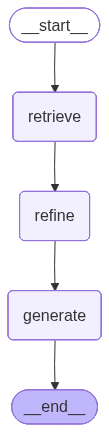

In [22]:
graph= StateGraph(CRAGState)
graph.add_node('retrieve', retrieve)
graph.add_node('generate', generate)
graph.add_node('refine', refine)

graph.add_edge(START, 'retrieve')
graph.add_edge('retrieve', 'refine')
graph.add_edge('refine', 'generate')
graph.add_edge('generate', END)

workflow= graph.compile()

workflow


In [23]:
res = workflow.invoke({
    "question": "Explain the bias-variance tradeoff",
    "docs": [],
    "strips": [],
    "kept_strips": [],
    "refined_context": "",
    "answer": ""
        })
print(res["answer"])

The bias-variance tradeoff refers to the balance between two sources of error in a model's predictions: bias and variance. 

Bias is the error introduced by approximating a real-world problem with a simplified model. High-bias models tend to make strong assumptions, such as assuming linearity when the data may have a more complex relationship (e.g., quadratic), resulting in underfitting the training data.

Variance, on the other hand, is the error caused by the model's sensitivity to small fluctuations in the training data. Models with high complexity (many degrees of freedom, such as high-degree polynomial models) often exhibit high variance, which can lead to overfitting the training data.

The tradeoff is that while flexible models can capture more intricate patterns in the data (low bias), they may also respond excessively to noise in the training data (high variance). Conversely, simpler models may have higher bias but less variance.

The goal is to find a model that achieves the 